# Fourier and Gate-Redundancy Analysis of Data-Reuploading Circuits

This notebook starts a research-oriented project on a deeper question than simply comparing classification accuracy:

> **When does another data-reuploading operation add a genuinely new mathematical capability, and when is it redundant?**

For each one-qubit circuit, we:

1. build its unitary matrix;
2. apply it to \(|0\rangle\);
3. calculate the \(Z\)-expectation value;
4. write the output as a Fourier series in the input \(x\);
5. identify frequencies and parameter-dependent coefficients;
6. look for gate simplifications.


## 1. Mathematical setup

A one-qubit state begins in

\[
|0\rangle=\begin{pmatrix}1\\0\end{pmatrix}.
\]

We use

\[
R_X(a)=e^{-iaX/2},\qquad
R_Y(a)=e^{-iaY/2},\qquad
R_Z(a)=e^{-iaZ/2}.
\]

The circuit output is

\[
f_\theta(x)=\langle\psi(x,\theta)|Z|\psi(x,\theta)\rangle.
\]

Because \(Z\) has eigenvalues \(+1\) and \(-1\),

\[
\langle Z\rangle=P(0)-P(1).
\]

The rightmost matrix acts first.


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sp.init_printing()

x, theta = sp.symbols("x theta", real=True)
I = sp.I

ket0 = sp.Matrix([1, 0])

X = sp.Matrix([[0, 1], [1, 0]])
Y = sp.Matrix([[0, -I], [I, 0]])
Z = sp.Matrix([[1, 0], [0, -1]])

def RX(angle):
    return sp.Matrix([
        [sp.cos(angle/2), -I*sp.sin(angle/2)],
        [-I*sp.sin(angle/2), sp.cos(angle/2)]
    ])

def RY(angle):
    return sp.Matrix([
        [sp.cos(angle/2), -sp.sin(angle/2)],
        [sp.sin(angle/2),  sp.cos(angle/2)]
    ])

def RZ(angle):
    return sp.Matrix([
        [sp.exp(-I*angle/2), 0],
        [0, sp.exp(I*angle/2)]
    ])

def final_state(unitary):
    return sp.simplify(unitary * ket0)

def expectation_z(unitary):
    psi = final_state(unitary)
    value = (sp.conjugate(psi.T) * Z * psi)[0]
    return sp.trigsimp(sp.simplify(sp.expand_complex(value)))

def fourier_coefficients(expression, variable=x, max_frequency=4):
    """Return nonzero complex Fourier coefficients c_k on [0, 2π]."""
    coefficients = {}
    for k in range(-max_frequency, max_frequency + 1):
        coefficient = sp.simplify(
            sp.integrate(
                expression * sp.exp(-I*k*variable),
                (variable, 0, 2*sp.pi)
            ) / (2*sp.pi)
        )
        coefficient = sp.trigsimp(coefficient)
        if coefficient != 0:
            coefficients[k] = coefficient
    return coefficients

def numerical_check(symbolic_expression, circuit, trials=5, seed=7):
    rng = np.random.default_rng(seed)
    errors = []

    for _ in range(trials):
        xv = float(rng.uniform(-np.pi, np.pi))
        tv = float(rng.uniform(-np.pi, np.pi))

        symbolic_value = complex(
            sp.N(symbolic_expression.subs({x: xv, theta: tv}))
        )

        U = np.array(
            circuit.subs({x: xv, theta: tv}).evalf(),
            dtype=complex
        )
        psi = U @ np.array([1.0, 0.0], dtype=complex)
        direct_value = np.vdot(
            psi,
            np.array([[1, 0], [0, -1]], dtype=complex) @ psi
        )

        errors.append(abs(symbolic_value - direct_value))

    return max(errors)

print("Setup complete.")


Setup complete.


## 2. Circuit 1 — one upload

\[
|\psi(x)\rangle=R_Y(x)|0\rangle.
\]

We derive the state and its \(Z\)-expectation value.


Final state:


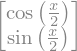

Z expectation:


Nonzero Fourier coefficients:


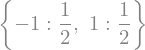

Maximum numerical verification error: 5.551115123125783e-17


In [2]:
U1 = RY(x)
psi1 = final_state(U1)
f1 = expectation_z(U1)
coeffs1 = fourier_coefficients(f1)

print("Final state:")
display(psi1)

print("Z expectation:")
display(f1)

print("Nonzero Fourier coefficients:")
display(coeffs1)

assert sp.simplify(f1 - sp.cos(x)) == 0
print("Maximum numerical verification error:", numerical_check(f1, U1))


The result is

\[
f(x)=\cos x=\frac{e^{ix}+e^{-ix}}{2}.
\]

Therefore,

\[
\Omega=\{-1,1\}.
\]


## 3. Circuit 2 — same-axis trainable rotation

\[
U_2(x,\theta)=R_Y(\theta)R_Y(x).
\]

Since the rotations share an axis,

\[
R_Y(\theta)R_Y(x)=R_Y(x+\theta).
\]

The second gate changes the phase of the function but not the frequency set.


Z expectation:


Nonzero Fourier coefficients:


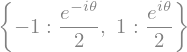

The two RY gates combine exactly into RY(x + theta).
Maximum numerical verification error: 1.6653345369377348e-16


In [3]:
U2 = RY(theta) * RY(x)
f2 = expectation_z(U2)
coeffs2 = fourier_coefficients(f2)

print("Z expectation:")
display(f2)

print("Nonzero Fourier coefficients:")
display(coeffs2)

assert sp.trigsimp(U2 - RY(x + theta)) == sp.zeros(2)
assert sp.simplify(f2 - sp.cos(x + theta)) == 0

print("The two RY gates combine exactly into RY(x + theta).")
print("Maximum numerical verification error:", numerical_check(f2, U2))


The output remains a first harmonic:

\[
\cos(x+\theta)
=
\frac{e^{i\theta}}{2}e^{ix}
+
\frac{e^{-i\theta}}{2}e^{-ix}.
\]

Thus the coefficients change, but

\[
\Omega=\{-1,1\}
\]

does not.


## 4. Circuit 3 — re-uploading separated by \(R_Z(\theta)\)

\[
U_3(x,\theta)=R_Y(x)R_Z(\theta)R_Y(x).
\]

Because \(R_Z\) and \(R_Y\) generally do not commute, the circuit cannot be collapsed in the same way.


Simplified Z expectation:


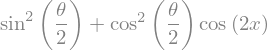

Nonzero Fourier coefficients:


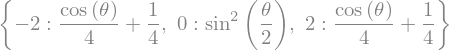

Maximum numerical verification error: 3.3306690738754696e-16


In [4]:
U3 = RY(x) * RZ(theta) * RY(x)
f3_raw = expectation_z(U3)

f3 = sp.trigsimp(
    sp.sin(theta/2)**2
    + sp.cos(theta/2)**2 * sp.cos(2*x)
)

coeffs3 = fourier_coefficients(f3)

print("Simplified Z expectation:")
display(f3)

print("Nonzero Fourier coefficients:")
display(coeffs3)

assert sp.simplify(sp.expand_complex(f3_raw - f3)) == 0
print("Maximum numerical verification error:", numerical_check(f3, U3))


The exact output is

\[
f_\theta(x)
=
\sin^2\left(\frac{\theta}{2}\right)
+
\cos^2\left(\frac{\theta}{2}\right)\cos(2x).
\]

The accessible frequency set is

\[
\Omega=\{-2,0,2\}.
\]

The second harmonic is parameter dependent:

- \(\theta=0\): \(f(x)=\cos(2x)\);
- \(\theta=\pi\): the second harmonic disappears and \(f(x)=1\).


## 5. Circuit 4 — re-uploading separated by \(R_X(\theta)\)

\[
U_4(x,\theta)=R_Y(x)R_X(\theta)R_Y(x).
\]


Simplified Z expectation:


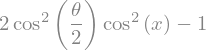

Nonzero Fourier coefficients:


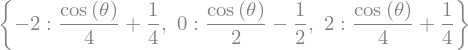

Maximum numerical verification error: 3.3306690738754696e-16


In [5]:
U4 = RY(x) * RX(theta) * RY(x)
f4_raw = expectation_z(U4)

f4 = sp.trigsimp(
    sp.cos(theta/2)**2 * sp.cos(2*x)
    - sp.sin(theta/2)**2
)

coeffs4 = fourier_coefficients(f4)

print("Simplified Z expectation:")
display(f4)

print("Nonzero Fourier coefficients:")
display(coeffs4)

assert sp.simplify(sp.expand_complex(f4_raw - f4)) == 0
print("Maximum numerical verification error:", numerical_check(f4, U4))


Circuit 4 also has

\[
\Omega=\{-2,0,2\},
\]

but its constant coefficient differs from Circuit 3. Therefore, two architectures can have the same accessible frequencies while representing different parameterized function families.


## 6. Visual comparison

These plots show the exact circuit-output functions. They are not training results.


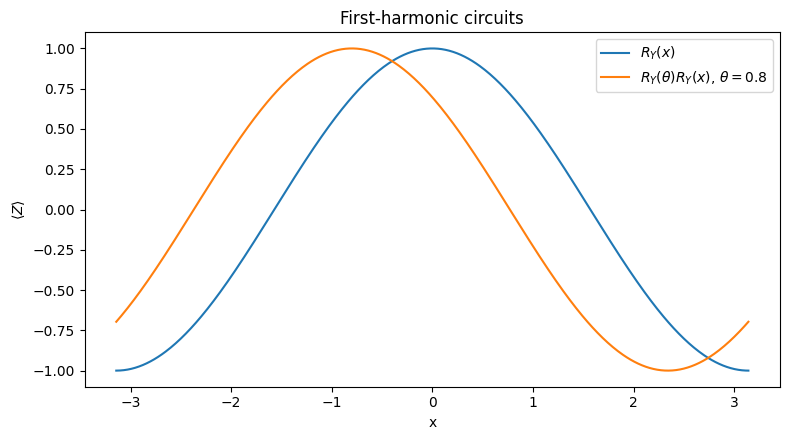

In [6]:
x_values = np.linspace(-np.pi, np.pi, 500)

def evaluate_expression(expression, theta_value=0.0):
    fn = sp.lambdify((x, theta), expression, "numpy")
    values = fn(x_values, theta_value)

    if np.isscalar(values):
        values = np.full_like(x_values, float(values), dtype=float)

    return np.asarray(values, dtype=float)

plt.figure(figsize=(8, 4.5))
plt.plot(x_values, evaluate_expression(f1), label=r"$R_Y(x)$")
plt.plot(
    x_values,
    evaluate_expression(f2, 0.8),
    label=r"$R_Y(\theta)R_Y(x)$, $\theta=0.8$"
)
plt.xlabel("x")
plt.ylabel(r"$\langle Z\rangle$")
plt.title("First-harmonic circuits")
plt.legend()
plt.tight_layout()
plt.show()


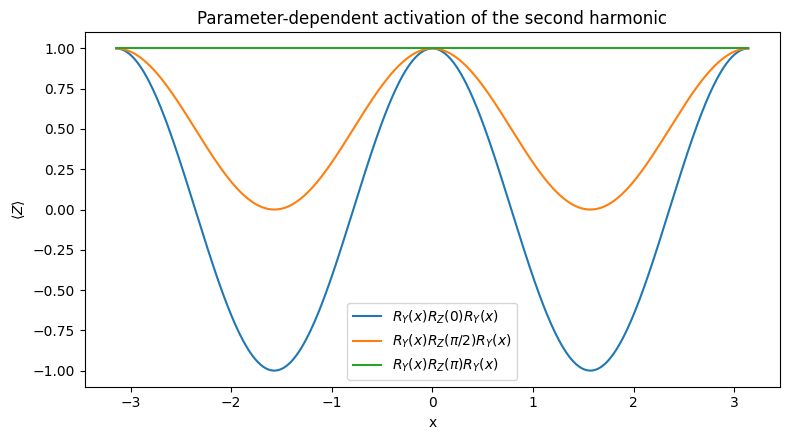

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(
    x_values,
    evaluate_expression(f3, 0.0),
    label=r"$R_Y(x)R_Z(0)R_Y(x)$"
)
plt.plot(
    x_values,
    evaluate_expression(f3, np.pi/2),
    label=r"$R_Y(x)R_Z(\pi/2)R_Y(x)$"
)
plt.plot(
    x_values,
    evaluate_expression(f3, np.pi),
    label=r"$R_Y(x)R_Z(\pi)R_Y(x)$"
)
plt.xlabel("x")
plt.ylabel(r"$\langle Z\rangle$")
plt.title("Parameter-dependent activation of the second harmonic")
plt.legend()
plt.tight_layout()
plt.show()


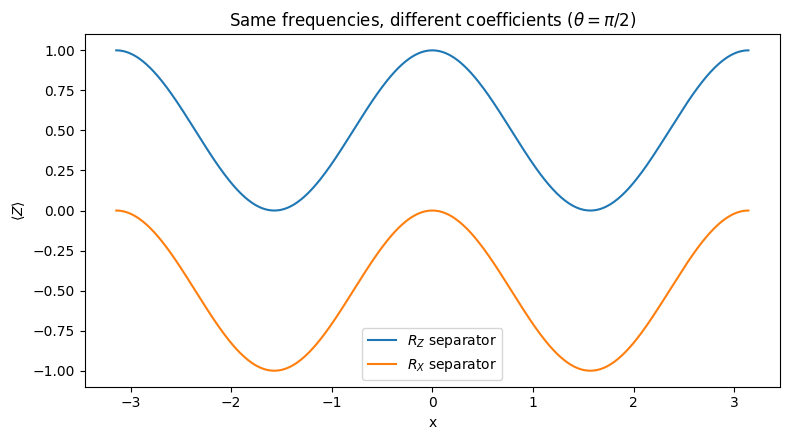

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(
    x_values,
    evaluate_expression(f3, np.pi/2),
    label=r"$R_Z$ separator"
)
plt.plot(
    x_values,
    evaluate_expression(f4, np.pi/2),
    label=r"$R_X$ separator"
)
plt.xlabel("x")
plt.ylabel(r"$\langle Z\rangle$")
plt.title(r"Same frequencies, different coefficients ($\theta=\pi/2$)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Preliminary catalogue

| Circuit | Exact \(Z\)-expectation | Frequencies | Main observation |
|---|---|---|---|
| \(R_Y(x)\) | \(\cos x\) | \(\{-1,1\}\) | One upload |
| \(R_Y(\theta)R_Y(x)\) | \(\cos(x+\theta)\) | \(\{-1,1\}\) | Gates merge exactly |
| \(R_Y(x)R_Z(\theta)R_Y(x)\) | \(\sin^2(\theta/2)+\cos^2(\theta/2)\cos(2x)\) | \(\{-2,0,2\}\) | Second harmonic |
| \(R_Y(x)R_X(\theta)R_Y(x)\) | \(-\sin^2(\theta/2)+\cos^2(\theta/2)\cos(2x)\) | \(\{-2,0,2\}\) | Same spectrum, different coefficients |


## 8. Next research tasks

### A. Enumerate short architectures

Generate circuits with two or three uploads and trainable separators chosen from \(R_X,R_Y,R_Z\).

### B. Distinguish three notions of redundancy

1. **Unitary redundancy:** same unitary up to global phase.
2. **Measurement redundancy:** different unitaries but the same selected expectation value.
3. **Function-family redundancy:** the same set of functions as parameters vary.

### C. Build automated tests

For each circuit:

- derive \(f_\theta(x)\);
- extract Fourier coefficients;
- detect mergeable adjacent rotations;
- identify parameter values that suppress frequencies;
- compare against smaller architectures.

### D. Extend only after the one-qubit case is understood

- two input features;
- mixed frequencies such as \(\cos(x+y)\);
- two qubits;
- one entangling gate;
- local versus joint measurements.


## 9. Possible contribution

A realistic contribution could be:

- a catalogue of minimal one-qubit re-uploading circuits for chosen frequency sets;
- a proof about which separators can activate particular coefficients;
- a counterexample showing that identical frequency sets do not imply identical function families;
- a symbolic tool that detects unitary, measurement, and function-family redundancy.


## References

1. A. Pérez-Salinas et al., **Data re-uploading for a universal quantum classifier**, *Quantum* 4, 226 (2020), arXiv:1907.02085.
2. M. Schuld, R. Sweke, and J. J. Meyer, **The effect of data encoding on the expressive power of variational quantum machine learning models**, *Physical Review A* 103, 032430 (2021), arXiv:2008.08605.
3. PennyLane documentation, **qml.fourier**.
